### Install Dependencies

In [1]:
import json
import gzip
import pandas as pd
import requests

In [47]:
with gzip.open("../../data/meta_Electronics.jsonl.gz", "rt") as f:
    first_line = json.loads(f.readline())

In [48]:
first_line

{'main_category': 'All Electronics',
 'title': 'FS-1051 FATSHARK TELEPORTER V3 HEADSET',
 'average_rating': 3.5,
 'rating_number': 6,
 'features': [],
 'description': ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.'],
 'price': None,
 'images': [{'thumb': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_US40_.jpg',
   'large': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.

In [49]:
first_line["details"]

{'Date First Available': 'August 2, 2014', 'Manufacturer': 'Fatshark'}

In [50]:
### Filter only recent items
def filter_data_by_date(data: dict) -> bool:
    filter = False
    if int(data["details"]["Date First Available"][-4:])<2022:
        filter = True

    return filter

In [51]:
with gzip.open("../../data/meta_Electronics.jsonl.gz", "rt") as fp:
    with open("../../data/meta_Electronics_2022_2023.jsonl", "a", encoding="utf-8") as fp_out:
        with open("../../data/meta_Electronics_2022_2023_no_date.jsonl", "a", encoding="utf-8") as fp_out_no_date:
            i=0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    filter = filter_data_by_date(data)
                    if not filter:
                        json.dump(data, fp_out)
                        fp_out.write("\n")
                        fp_out.flush()
                except:
                    json.dump(data, fp_out_no_date)
                    fp_out_no_date.write("\n")
                    fp_out_no_date.flush()
                i+=1
                if i%100000==0:
                    print(f"Processed {i} lines")
                    

Processed 100000 lines
Processed 200000 lines
Processed 300000 lines
Processed 400000 lines
Processed 500000 lines
Processed 600000 lines
Processed 700000 lines
Processed 800000 lines
Processed 900000 lines
Processed 1000000 lines
Processed 1100000 lines
Processed 1200000 lines
Processed 1300000 lines
Processed 1400000 lines
Processed 1500000 lines
Processed 1600000 lines


In [52]:
### Split the items into two categories

def filter_category(data: dict) -> dict:
    filter = False
    if data["main_category"] == None:
        filter = True
    return filter

In [53]:
with open("../../data/meta_Electronics_2022_2023.jsonl", "r") as fp:
    with open("../../data/meta_Electronics_2022_2023_with_category.jsonl", "a", encoding="utf-8") as fp_out:
        with open("../../data/meta_Electronics_2022_2023_no_category.jsonl", "a", encoding="utf-8") as fp_out_no_category:
            i=0
            for line in fp:
                data = json.loads(line.strip())
                if not filter_category(data):
                    json.dump(data, fp_out)
                    fp_out.write("\n")
                    fp_out.flush()
                else:
                    json.dump(data, fp_out_no_category)
                    fp_out_no_category.write("\n")
                    fp_out_no_category.flush()
                i+=1
                if i%10000==0:
                    print(f"Processed {i} lines")
        

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
Processed 100000 lines
Processed 110000 lines


In [54]:
### Explore distribution by categories

df = pd.read_json("../../data/meta_Electronics_2022_2023_with_category.jsonl", lines=True)

In [55]:
len(df)

103993

<Axes: xlabel='main_category'>

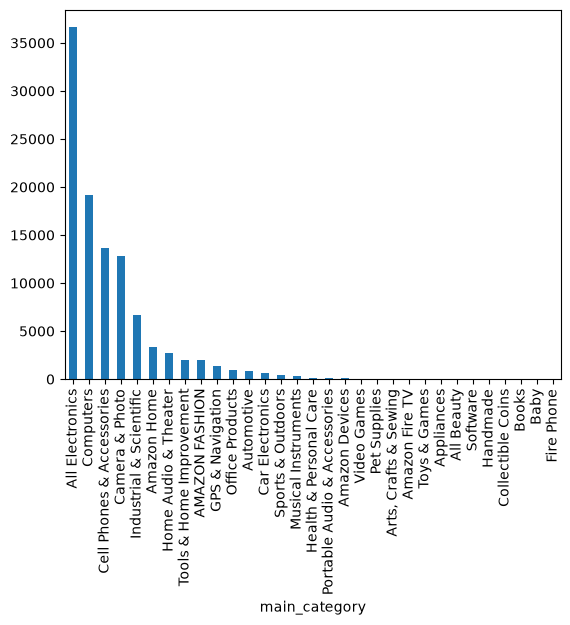

In [56]:
df['main_category'].value_counts().plot(kind='bar')

In [57]:
### Filter items with >100 ratings - not going to do this since books has very little dates

df_ratings_100 = df[df['rating_number']>=100]

In [58]:
print(len(df_ratings_100))

17290


<Axes: xlabel='main_category'>

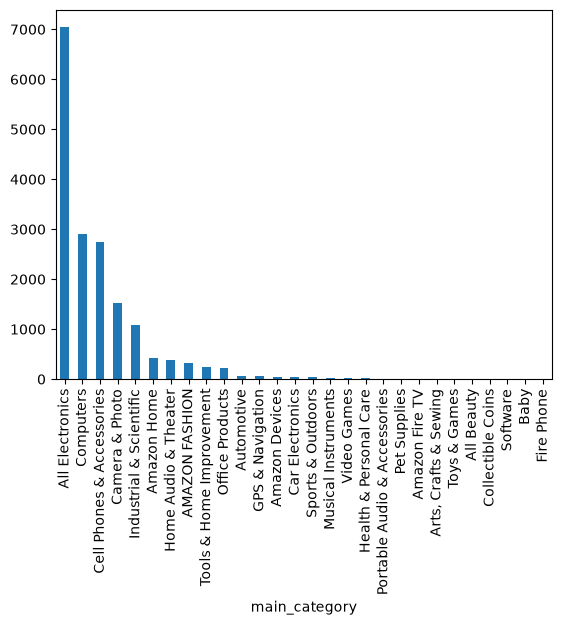

In [59]:
df_ratings_100['main_category'].value_counts().plot(kind='bar')

<Axes: >

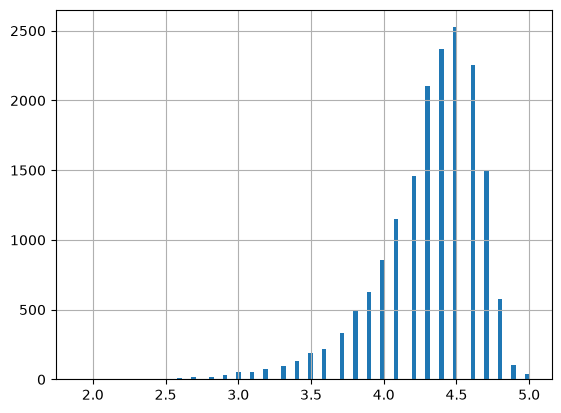

In [60]:
## explore distribution of ratings

df_ratings_100['average_rating'].hist(bins=100)

<Axes: >

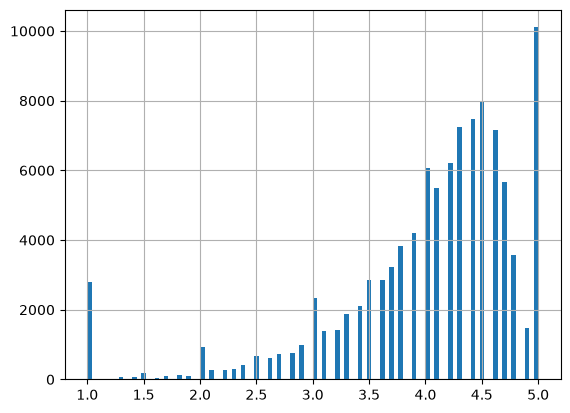

In [61]:
df['average_rating'].hist(bins=100)

In [62]:
### Sample 1000 items
df_sample_1000 = df_ratings_100.sample(1000, random_state=42)

In [63]:
df_sample_1000.to_json("../../data/meta_Electronics_2022_2023_with_category_ratings_100_sample_1000.jsonl", orient="records", lines=True)
df_ratings_100.to_json("../../data/meta_Electronics_2022_2023_with_category_ratings_100.jsonl", orient="records", lines=True)

In [64]:
### Extract ratinggs that match sample data
df_sample_1000 = pd.read_json("../../data/meta_Electronics_2022_2023_with_category_ratings_100_sample_1000.jsonl", lines=True)
df_ratings_100 = pd.read_json("../../data/meta_Electronics_2022_2023_with_category_ratings_100.jsonl", lines=True)

In [65]:
with gzip.open("../../data/Electronics.jsonl.gz", "r") as fp:
    with open("../../data/Electronics_2022_2023_with_category_ratings_100_sample_1000.jsonl", "a", encoding="utf-8") as fp_out:
        id_list = set(df_sample_1000['parent_asin'].values)
        i=0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write("\n")
                fp_out.flush()
            i+=1
            if i%100000==0:
                print(f"Processed {i} lines")


Processed 100000 lines
Processed 200000 lines
Processed 300000 lines
Processed 400000 lines
Processed 500000 lines
Processed 600000 lines
Processed 700000 lines
Processed 800000 lines
Processed 900000 lines
Processed 1000000 lines
Processed 1100000 lines
Processed 1200000 lines
Processed 1300000 lines
Processed 1400000 lines
Processed 1500000 lines
Processed 1600000 lines
Processed 1700000 lines
Processed 1800000 lines
Processed 1900000 lines
Processed 2000000 lines
Processed 2100000 lines
Processed 2200000 lines
Processed 2300000 lines
Processed 2400000 lines
Processed 2500000 lines
Processed 2600000 lines
Processed 2700000 lines
Processed 2800000 lines
Processed 2900000 lines
Processed 3000000 lines
Processed 3100000 lines
Processed 3200000 lines
Processed 3300000 lines
Processed 3400000 lines
Processed 3500000 lines
Processed 3600000 lines
Processed 3700000 lines
Processed 3800000 lines
Processed 3900000 lines
Processed 4000000 lines
Processed 4100000 lines
Processed 4200000 lines
P